# CHOMP optimizer — tests & comparison with the WarmStartPlanner

CHOMP is a classical, learning-free trajectory optimizer. It minimizes collision + joint-limits +
smoothness via a covariant gradient update with fixed start/goal, and can be warm-started from a
model trajectory.

**Fair comparison.** CHOMP is built from the same `losses.py` terms the WarmStartPlanner is trained
on, so we point it at the **loaded model's own loss weights** (`TRAIN_LOSS`, from the
`wsp_general_0907_v1` run in `process_nvidia_1_sample.ipynb`) rather than `chomp.py`'s defaults.
Otherwise the model would be competing against an optimizer chasing a different objective.
The step cap `ETA` is *not* part of that loss — it is tuned separately, per init (see section 1).

**Scoring** is independent of both: `TrajectoryEvaluator` judges every method on geometric
feasibility (`collision_free`, `n_collision_pts`, `min_clearance`) computed from the robot sphere
*surface* clearance, plus raw smoothness and path lengths. None of those depend on cost weights.

**Headline finding:** feasibility/smoothness over a 60-sample probe, timings from a 20-sample run —

| | collision-free | mean smooth | joint-limit trials | iters | speed |
|---|---|---|---|---|---|
| model | 53/60 | 1.05 | 4 | — | ~7 ms |
| CHOMP from scratch (`eta=300`) | 48/60 | 0.96 | 12 | 12.5 | ~93 ms |
| **model + CHOMP** (`eta=1500`) | **60/60** | **0.96** | **0** | **2.2** | **~30 ms** |

CHOMP from a straight-line init stays stuck in local minima and still violates joint limits in
12/60 trials (the covariant update never projects onto `[q_min, q_max]` — the limits are only a soft
penalty, hopelessly outweighed by `w_coll=350`). Warm-started from the model it converges in ~2
iterations to a trajectory that beats the model on feasibility *and* smoothness, with no limit
violations at all, and is **3x faster than CHOMP from scratch**: **model → CHOMP is genuinely the
best of both.**

⚠️ **Never read a collision-free rate on its own, and always sanity-check the timings.** Three traps
this notebook has already fallen into:
* `mean_iters ≈ 1` means CHOMP stopped at its first check and passed the model output through
  unchanged — a no-op, not a refinement.
* Before `optimize` gained its backtracking line search, a fixed step on this stiff cost overshot,
  oscillated, and reached "collision-free" by flinging the arm around: 20/20 collision-free at mean
  smoothness 7.2 and worst case 50.7, i.e. trajectories no robot would execute. It also left
  warm-started trajectories *worse* than the model's own output (cost rose on 223 of 499 steps).
  Read `max_smooth` and `max_joint_viol` alongside.
* Warm start used to be *slower* than from-scratch despite 4x fewer iterations, because
  `init_trajectory` rebuilt the ~75 ms B-spline matrix on every call (now cached). If iterations
  drop but time does not, the cost is not in the optimization.

In [1]:
# ---- Setup ----
import sys, os, time
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

SIMPLEARM_PATH = os.path.abspath("../external/SimpleArm/src")
sys.path.insert(0, SIMPLEARM_PATH)

from simplearm.robot import RobotInfo
from simplearm.geom import Obstacles
from simplearm.viz import RobotViewer

from chomp import CHOMPOptimizer
from evaluation import TrajectoryEvaluator
import models
from visualization import save_viewer_as_gif

DEVICE = "cpu"
GRID_LENGTH = 2.5
torch.manual_seed(0)
np.random.seed(0)

## 1. Load the Bigboy dataset & trained model

`CHOMPOptimizer.from_metadata` builds robot / joint-limits / grid straight from the dataset metadata
(same setup as `training.train`).

In [2]:
DATASET_PATH = "data/dataset_general_0807_test.pt"
MODEL_PATH   = "models/wsp_general_0907_v1.pt"

ds   = torch.load(DATASET_PATH, weights_only=False)
meta = ds["metadata"]

# CHOMP optimizes the SAME loss the loaded model was trained on, so the comparison is fair:
# the model cannot look good merely because CHOMP was pointed at a different objective.
# Weights taken from the wsp_general_0907_v1 training run in process_nvidia_1_sample.ipynb.
# Deviation: training aggregates the collision cost with 'max' (worst timestep only), which
# carries gradient through a single waypoint and stalls a trajectory optimizer. 'sum' is the
# same per-step cost aggregated over all timesteps — better suited to CHOMP.
TRAIN_LOSS = dict(eps=0.15, w_coll=350.0, w_joints=1.0, w_smooth=1.0, collision_agg="sum")

# eta is CHOMP's step size, NOT part of the loss — training used Adam with lr=5e-4, which says
# nothing about a covariant descent, so it is tuned separately here. Since optimize() backtracks
# (halving until the cost decreases), eta only caps the LARGEST step considered: a small eta lets
# the descent move fast where that is safe, and the line search reins it in where it is not.
# Measured over 60 samples — the two inits genuinely prefer different caps, so each gets its best
# rather than handicapping one of them:
#   scratch: eta=300 -> 48/60 collision-free (1500 would give only 42/60)
#   warm:    eta=1500 -> 60/60 collision-free in 2.2 iterations (300 would give 58/60)
ETA_SCRATCH = 300
ETA_WARM    = 1500

chomp = CHOMPOptimizer.from_metadata(meta, T=50, device=DEVICE, **TRAIN_LOSS)
print("optimizer HP :", dict(eps=chomp.eps, w_coll=chomp.w_coll, w_joints=chomp.w_joints,
                             w_smooth=chomp.w_smooth, agg=chomp.collision_agg),
      "| eta scratch/warm:", (ETA_SCRATCH, ETA_WARM))

# Scoring is independent of the optimizer: every method is judged by the same evaluator on
# geometric feasibility (collision_free / n_collision_pts / min_clearance, from the sphere
# SURFACE clearance) plus raw smoothness and path lengths. None of those depend on cost
# weights, so there is no second weight set to keep in sync.
ev    = TrajectoryEvaluator.from_metadata(meta, device=DEVICE)
robot = chomp.robot

model = models.WarmStartPlanner(dof=meta["dof"], T=50, C=10, linklengths=meta["linklengths"]).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
model.eval()
print("\nLoaded model:", MODEL_PATH, "| dataset N =", meta["N"])

optimizer HP : {'eps': 0.15, 'w_coll': 350.0, 'w_joints': 1.0, 'w_smooth': 1.0, 'agg': 'sum'} | eta scratch/warm: (300, 1500)

Loaded model: models/wsp_general_0907_v1.pt | dataset N = 1501


## 2. One sample: model vs. CHOMP-from-scratch vs. model→CHOMP

Pick a sample where the model output still collides, and compare the three trajectories on it.
`chomp` here runs the model's own `TRAIN_LOSS` weights (see section 1).

⚠️ **The sample is hardcoded to `i = 24`, and it is an outlier — do not generalise from its GIF.**
On this one sample CHOMP swings joint 0 out to +4.85 rad where the model only reaches +3.26
(overshoot 3.03 vs. 1.44, joint path 7.60 vs. 5.19): the arm rounds the obstacle correctly, then
keeps going and has to come back. Across 60 samples that is *not* the typical behaviour — mean
overshoot is 1.78 for model→CHOMP vs. 1.83 for the model alone, i.e. CHOMP swings slightly *less*
than the model on average.

The cause is the exponential `repulsion` term in `losses._compute_sphere_costs`, which never decays
to zero and so keeps pushing the arm away from obstacles no matter how much clearance it already
has. It is a *training* aid (it gives the network gradient everywhere so the smoothness term cannot
silently drag it into obstacles); training also aggregates collisions with `max`, so it only ever
acts on one timestep. CHOMP uses `sum`, so it acts at every timestep at once, and `w_coll=350`
against `w_smooth=1` means smoothness cannot hold it back.

Disabling it *does* fix this sample (overshoot 1.35, joint path 5.13, still collision-free — better
than the model), but over 60 samples it costs feasibility: 56/60 collision-free instead of 60/60.
Raising `w_smooth` to 10 cuts mean overshoot to 0.83 but drops to 47/60 — worse than the model's
53/60. **Overshoot and collision-free rate trade off directly: the arm swings wide precisely
because that is what clears the obstacle.** The notebook keeps the training weights (60/60).

In [12]:
# Find a sample where the model output collides but model->CHOMP fixes it
# (the compelling before/after). Fall back to the first colliding sample.
i, fallback = 20, None
for k in range(min(40, meta["N"])):
    sk, qk, gk = ds["sdf"][k:k+1], ds["q_start"][k:k+1], ds["q_goal"][k:k+1]
    with torch.no_grad():
        wp_k = model(qk, gk, sk)
    if ev.evaluate(model.trajectory(wp_k), sk)["collision_free"]:
        continue
    if fallback is None:
        fallback = k
    tr_k = chomp.optimize(sk, qk, gk, init_waypoints=wp_k, max_iters=300, eta=ETA_WARM)
    if ev.evaluate(tr_k, sk)["collision_free"]:
        i = k; break
i = i if i is not None else (fallback if fallback is not None else 0)
print(f"Using sample {i} (model output collides)")
i = 26
sdf_i = ds["sdf"][i]
qs_i  = ds["q_start"][i:i+1]
qg_i  = ds["q_goal"][i:i+1]
n_obs = ds["n_obstacles"][i].item()
obs_i = ds["obstacles"][i, :n_obs]
obstacles_i = Obstacles(x=obs_i[:, 0].numpy(), y=obs_i[:, 1].numpy(), r=obs_i[:, 2].numpy())

# --- model --- (forward pass only)
t0 = time.time()
with torch.no_grad():
    wp_i       = model(qs_i, qg_i, sdf_i.unsqueeze(0))
    traj_model = model.trajectory(wp_i)
t_model = time.time() - t0

# --- CHOMP from scratch --- optimize until convergence (collision-free OR cost plateau).
t0 = time.time()
traj_scratch, hist = chomp.optimize(sdf_i, qs_i, qg_i, max_iters=500, eta=ETA_SCRATCH,
                                    return_history=True)
t_scratch = time.time() - t0

# --- model + CHOMP --- warm-started refinement (includes the model forward pass above).
t0 = time.time()
traj_refined = chomp.optimize(sdf_i, qs_i, qg_i, init_waypoints=wp_i, max_iters=500, eta=ETA_WARM)
t_refined = t_model + (time.time() - t0)
print(f"CHOMP-from-scratch ran {len(hist)} iterations until convergence\n")

times = {"model": t_model, "CHOMP scratch": t_scratch, "model+CHOMP": t_refined}

import pandas as pd
rows = {}
for name, tr in [("model", traj_model), ("CHOMP scratch", traj_scratch),
                 ("model+CHOMP", traj_refined)]:
    e = ev.evaluate(tr, sdf_i)
    e["time_ms"] = times[name] * 1e3
    rows[name] = e
pd.DataFrame(rows).T[["collision_free", "n_collision_pts", "min_clearance",
                      "smooth", "joint_path_length", "ee_path_length", "time_ms"]]

Using sample 10 (model output collides)
CHOMP-from-scratch ran 31 iterations until convergence



,collision_free,n_collision_pts,min_clearance,smooth,joint_path_length,ee_path_length,time_ms
model,True,0,0.037312,1.136363,8.636522,2.659958,7.856846
CHOMP scratch,True,0,0.009261,0.686431,6.665484,3.401114,264.111757
model+CHOMP,True,0,0.045457,1.098533,8.491053,2.644178,18.237829


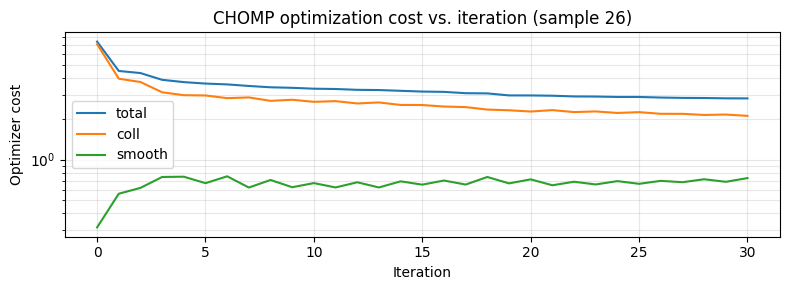

In [13]:
# ---- CHOMP-from-scratch optimization cost vs. iteration ----
fig, ax = plt.subplots(figsize=(8, 3))
for key in ["total", "coll", "smooth"]:
    ax.plot([h[key] for h in hist], label=key)
ax.set_xlabel("Iteration"); ax.set_ylabel("Optimizer cost"); ax.set_yscale("log")
ax.legend(); ax.grid(True, which="both", alpha=0.3)
ax.set_title(f"CHOMP optimization cost vs. iteration (sample {i})")
plt.tight_layout(); plt.show()

In [14]:
# ---- Before / after visualization (model vs. CHOMP-from-scratch vs. model+CHOMP) ----
for label, tr in [("model", traj_model), ("CHOMP from scratch", traj_scratch),
                  ("model + CHOMP", traj_refined)]:
    print(label)
    viz = RobotViewer(tr.squeeze(0).cpu().numpy(), robot, obstacles=obstacles_i, animate=True)
    viz.plot()
    #save_viewer_as_gif(viz, f"resources/{label}_sample_{i}.gif", duration_ms=120)

# Save the refined trajectory as a GIF
#viz = RobotViewer(traj_refined.squeeze(0).cpu().numpy(), robot, obstacles=obstacles_i, animate=True)
#viz.plot()
#save_viewer_as_gif(viz, f"resources/model_chomp_sample_{i}.gif", duration_ms=60)

model
⠸ Plotting robot... (0:00:00.75) 

CHOMP from scratch               
⠼ Plotting robot... (0:00:01.09) 

model + CHOMP                    
⠴ Plotting robot... (0:00:01.14) 

## 3. Speed & final-result comparison over many samples

The main comparison: collision-free rate, **iterations-to-convergence**, and wall-clock speed for
five methods, all judged on the same evaluation metric. Every CHOMP run uses `TRAIN_LOSS` — the
weights the loaded model was trained on — so no method is handicapped by a different objective:

1. **model** — forward pass only.
2. **CHOMP from scratch** — CHOMP on `TRAIN_LOSS` (collision + joint limits + smoothness) from a
   straight line.
3. **CHOMP + extra losses** — same, plus the **exploration** and **waypoint-spacing** terms the
   model was also trained on (`w_explore=5`, `w_spacing=2`, `explore_threshold=0.5`). Together with
   (2) this isolates what those two terms contribute.
4. **model + CHOMP** — CHOMP refinement warm-started from the model output.
5. **model + CHOMP + extra losses** — the same refinement with the extra losses enabled.

CHOMP runs until convergence (collision-free *or* cost plateau, capped at `max_iters`) — **not** a
fixed iteration count — so the time/iteration numbers are meaningful. Watch `mean_iters` for the
warm-started rows: if it is ~1, CHOMP stopped at its first collision-free check and effectively
passed the model output through unchanged, which makes that row a no-op rather than a refinement.
CHOMP is still ~50-100x slower per sample, so keep `N_COMPARE` modest.

In [16]:
import pandas as pd

N_COMPARE = 500
idxs = list(range(N_COMPARE))
sdf  = ds["sdf"][idxs]
qs   = ds["q_start"][idxs]
qg   = ds["q_goal"][idxs]

# Second optimizer: the same TRAIN_LOSS as `chomp`, plus the exploration and waypoint-spacing
# terms the model was also trained on (w_explore=5, w_spacing=2, explore_threshold=0.5).
# The only difference to `chomp` is those two terms, so the pairs below isolate their effect.
# Caveat: training applies them to the C=10 control points, chomp.py to the T=50 dense
# trajectory, where the spacing variance is ~27x smaller — the weights are not directly
# comparable across the two call sites.
chomp_ex = CHOMPOptimizer.from_metadata(meta, T=50, device=DEVICE, **TRAIN_LOSS,
                                        w_explore=5.0, w_spacing=2.0,
                                        explore_threshold=0.5)

# One colour per method, reused by every plot below.
METHODS = ["model", "CHOMP from scratch", "CHOMP + extra losses",
           "model + CHOMP", "model + CHOMP + extra losses"]
COLORS  = {"model":                       "#1f77b4",
           "CHOMP from scratch":          "#ff7f0e",
           "CHOMP + extra losses":        "#d62728",
           "model + CHOMP":               "#2ca02c",
           "model + CHOMP + extra losses": "#9467bd"}


def joint_violation(traj):
    """Max amount (rad) by which any joint exceeds its limit over the trajectory (0 if within)."""
    tr = traj.to(ev.device).float()
    tr = tr.unsqueeze(0) if tr.ndim == 2 else tr
    over = torch.maximum((ev.q_min - tr).clamp(min=0), (tr - ev.q_max).clamp(min=0))
    return float(over.max().item())


def evaluate_sample(tr, sdf_k):
    """Standard evaluation + an explicit joint-limit violation (rad) per trial."""
    e = ev.evaluate(tr, sdf_k)
    e["joint_violation"] = joint_violation(tr)
    return e


# Batched warmstart waypoints (reused by the model+CHOMP runs below).
with torch.no_grad():
    wp = model(qs, qg, sdf)

# --- Model --- time each sample individually so we get a per-sample distribution.
model_evals, model_times = [], []
for k in range(N_COMPARE):
    t0 = time.time()
    with torch.no_grad():
        wp_k = model(qs[k:k+1], qg[k:k+1], sdf[k:k+1])
        tr_k = model.trajectory(wp_k)
    model_times.append(time.time() - t0)
    model_evals.append(evaluate_sample(tr_k, sdf[k:k+1]))


def run_chomp(opt, use_warmstart, desc):
    """Optimize each sample until convergence; return (evals, per-sample times, iters).

    Each init gets its own best step cap (see ETA_SCRATCH / ETA_WARM in section 1).
    """
    eta = ETA_WARM if use_warmstart else ETA_SCRATCH
    evals, iters, times = [], [], []
    for k in tqdm(range(N_COMPARE), desc=desc):
        kw = dict(init_waypoints=wp[k:k+1]) if use_warmstart else {}
        t0 = time.time()
        tr, h = opt.optimize(sdf[k:k+1], qs[k:k+1], qg[k:k+1], max_iters=500, eta=eta,
                             return_history=True, **kw)
        times.append(time.time() - t0)
        evals.append(evaluate_sample(tr, sdf[k:k+1]))
        iters.append(len(h))
    return evals, times, iters


scratch_evals,    scratch_times,    scratch_iters    = run_chomp(chomp,    False, "CHOMP scratch")
scratch_ex_evals, scratch_ex_times, scratch_ex_iters = run_chomp(chomp_ex, False, "CHOMP scratch + extra")
refine_evals,     refine_chomp_times,    refine_iters    = run_chomp(chomp,    True, "model+CHOMP")
refine_ex_evals,  refine_ex_chomp_times, refine_ex_iters = run_chomp(chomp_ex, True, "model+CHOMP + extra")
# model+CHOMP per-sample time = model forward + CHOMP refinement.
refine_times    = [model_times[k] + refine_chomp_times[k]    for k in range(N_COMPARE)]
refine_ex_times = [model_times[k] + refine_ex_chomp_times[k] for k in range(N_COMPARE)]

# Per-method results kept around for the distribution plots in the next cell.
results = {
    "model":                        dict(evals=model_evals,      iters=None,             times=model_times),
    "CHOMP from scratch":           dict(evals=scratch_evals,    iters=scratch_iters,    times=scratch_times),
    "CHOMP + extra losses":         dict(evals=scratch_ex_evals, iters=scratch_ex_iters, times=scratch_ex_times),
    "model + CHOMP":                dict(evals=refine_evals,     iters=refine_iters,     times=refine_times),
    "model + CHOMP + extra losses": dict(evals=refine_ex_evals,  iters=refine_ex_iters,  times=refine_ex_times),
}


def summarise(r):
    evals, n = r["evals"], len(r["evals"])
    crashed   = [not e["collision_free"] for e in evals]            # >=1 collision point
    jviol     = [e["joint_violation"] for e in evals]
    smooth    = [e["smooth"] for e in evals]
    return {
        "crash_free":          f"{n - sum(crashed)}/{n}",
        "crash_free_rate":     1 - sum(crashed) / n,
        "crashed_trials":      sum(crashed),
        "mean_collisions":     np.mean([e["n_collision_pts"] for e in evals]),
        "max_collisions":      int(np.max([e["n_collision_pts"] for e in evals])),
        "mean_min_clear":      np.mean([e["min_clearance"] for e in evals]),
        "mean_smooth":         np.mean(smooth),
        # A collision-free rate bought with jerky trajectories is not a win — a max far above
        # the mean means CHOMP flung the arm around and stopped wherever it happened to be free.
        "max_smooth":          np.max(smooth),
        "joint_limit_trials":  int(sum(v > 1e-6 for v in jviol)),
        "max_joint_viol":      np.max(jviol),
        "mean_iters":          (np.mean(r["iters"]) if r["iters"] is not None else np.nan),
        "total_time_s":        np.sum(r["times"]),
        "mean_ms_per_sample":  np.mean(r["times"]) * 1e3,
    }


summary = pd.DataFrame({m: summarise(results[m]) for m in METHODS}).T
summary.round(3)

CHOMP scratch:   0%|          | 0/500 [00:00<?, ?it/s]

CHOMP scratch + extra:   0%|          | 0/500 [00:00<?, ?it/s]

model+CHOMP:   0%|          | 0/500 [00:00<?, ?it/s]

model+CHOMP + extra:   0%|          | 0/500 [00:00<?, ?it/s]

,crash_free,crash_free_rate,crashed_trials,mean_collisions,max_collisions,mean_min_clear,mean_smooth,max_smooth,joint_limit_trials,max_joint_viol,mean_iters,total_time_s,mean_ms_per_sample
model,443/500,0.886,57,2.248,73,0.087914,1.064041,2.775875,15,0.200373,NaN,4.771885,9.54377
CHOMP from scratch,353/500,0.706,147,1.552,18,0.032176,0.933377,9.963174,78,3.786602,15.098,79.786479,159.572959
CHOMP + extra losses,355/500,0.71,145,1.536,18,0.026982,2.297101,37.148052,112,12.461636,15.784,147.588182,295.176365
model + CHOMP,486/500,0.972,14,0.162,16,0.069024,0.985262,2.762492,7,2.036042,3.398,20.164214,40.328429
model + CHOMP + extra losses,485/500,0.97,15,0.174,13,0.068254,0.977513,2.825663,5,2.035478,3.506,30.349096,60.698193


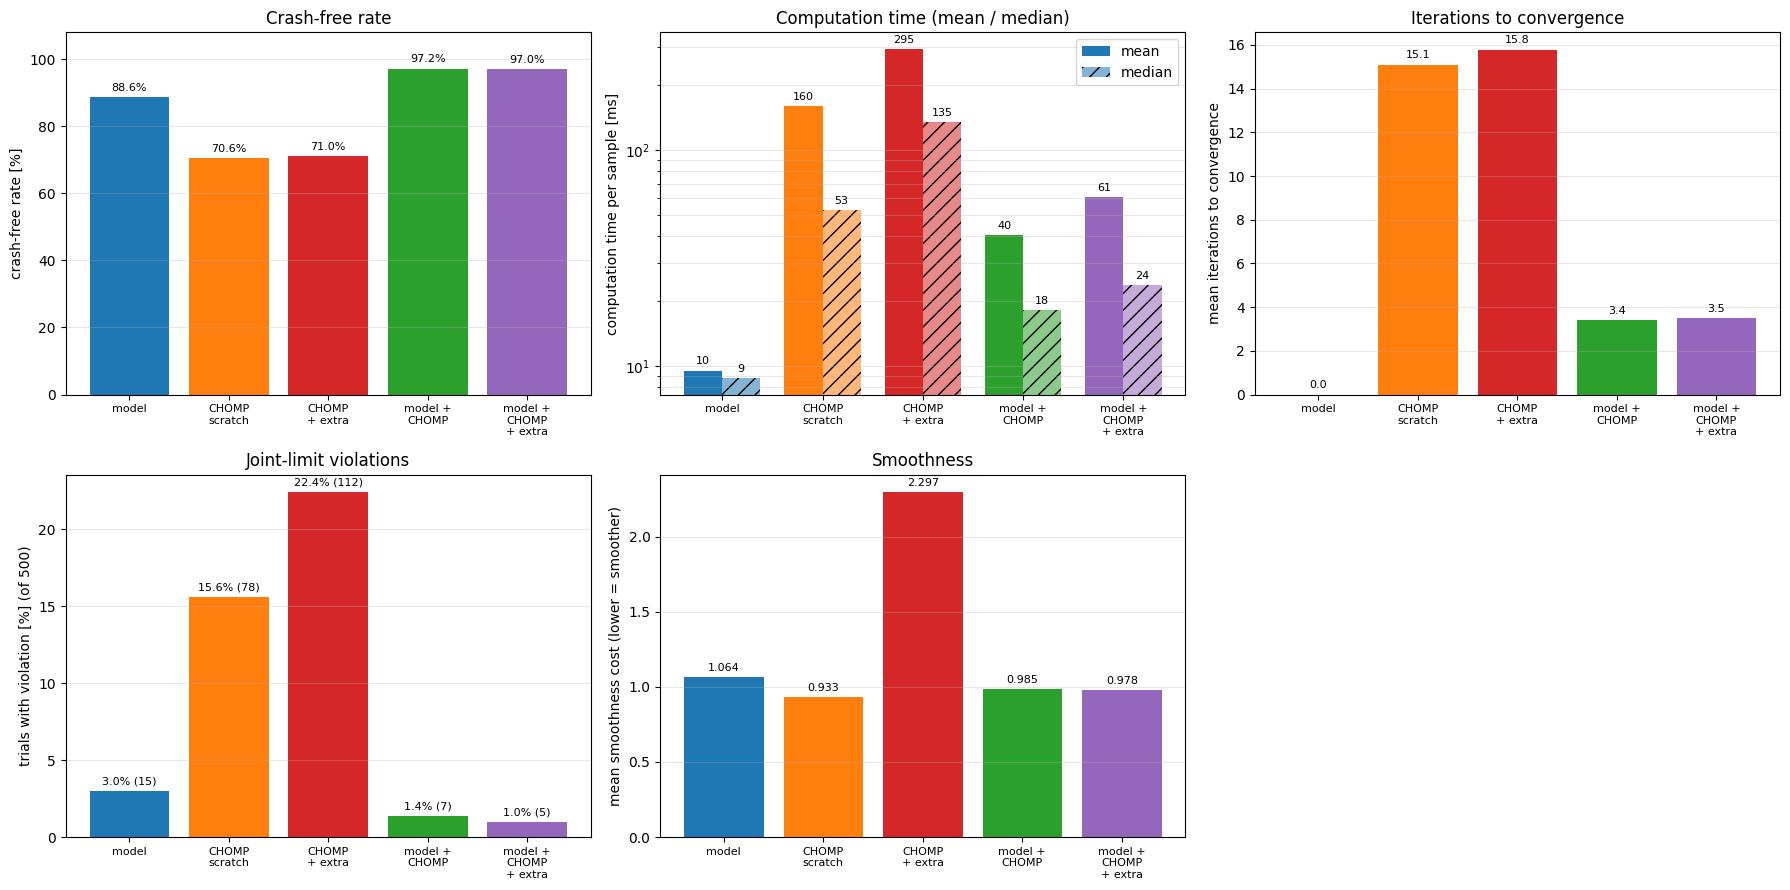

In [17]:
# ---- Bar-chart summary: crash-free rate, computation time, iterations, joint violations, smoothness ----
short = {"model": "model", "CHOMP from scratch": "CHOMP\nscratch",
         "CHOMP + extra losses": "CHOMP\n+ extra", "model + CHOMP": "model +\nCHOMP",
         "model + CHOMP + extra losses": "model +\nCHOMP\n+ extra"}
labels = [short[m] for m in METHODS]
bar_colors = [COLORS[m] for m in METHODS]
x = np.arange(len(METHODS))
n = len(results[METHODS[0]]["evals"])

crash_free  = [1 - sum(not e["collision_free"] for e in results[m]["evals"]) / len(results[m]["evals"])
               for m in METHODS]
mean_ms     = [np.mean(results[m]["times"])   * 1e3 for m in METHODS]
median_ms   = [np.median(results[m]["times"]) * 1e3 for m in METHODS]
mean_iters  = [np.mean(results[m]["iters"]) if results[m]["iters"] is not None else 0 for m in METHODS]
jviol_count = [sum(e["joint_violation"] > 1e-6 for e in results[m]["evals"]) for m in METHODS]
jviol_pct   = [c / n * 100 for c in jviol_count]
mean_smooth = [np.mean([e["smooth"] for e in results[m]["evals"]]) for m in METHODS]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# (1) Crash-free rate.
ax = axes[0, 0]
bars = ax.bar(x, [c * 100 for c in crash_free], color=bar_colors)
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("crash-free rate [%]"); ax.set_ylim(0, 108)
ax.set_title("Crash-free rate"); ax.grid(axis="y", alpha=0.3)

# (2) Computation time — mean vs. median, grouped (log scale spans model ~ms to CHOMP ~s).
ax = axes[0, 1]
w = 0.38
b1 = ax.bar(x - w/2, mean_ms,   w, label="mean",   color=bar_colors)
b2 = ax.bar(x + w/2, median_ms, w, label="median", color=bar_colors, alpha=0.55, hatch="//")
ax.bar_label(b1, fmt="%.0f", padding=3, fontsize=8)
ax.bar_label(b2, fmt="%.0f", padding=3, fontsize=8)
ax.set_yscale("log")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("computation time per sample [ms]")
ax.set_title("Computation time (mean / median)"); ax.legend(); ax.grid(axis="y", which="both", alpha=0.3)

# (3) Mean iterations to convergence (model has none — pure forward pass).
ax = axes[0, 2]
bars = ax.bar(x, mean_iters, color=bar_colors)
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("mean iterations to convergence")
ax.set_title("Iterations to convergence"); ax.grid(axis="y", alpha=0.3)

# (4) Joint-limit violations — share of trials that overshoot any joint limit.
ax = axes[1, 0]
bars = ax.bar(x, jviol_pct, color=bar_colors)
ax.bar_label(bars, labels=[f"{p:.1f}% ({c})" for p, c in zip(jviol_pct, jviol_count)],
             padding=3, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel(f"trials with violation [%] (of {n})")
ax.set_title("Joint-limit violations"); ax.grid(axis="y", alpha=0.3)

# (5) Smoothness — mean smoothness cost (lower = smoother).
ax = axes[1, 1]
bars = ax.bar(x, mean_smooth, color=bar_colors)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("mean smoothness cost (lower = smoother)")
ax.set_title("Smoothness"); ax.grid(axis="y", alpha=0.3)

axes[1, 2].axis("off")  # unused panel

plt.tight_layout(); plt.show()


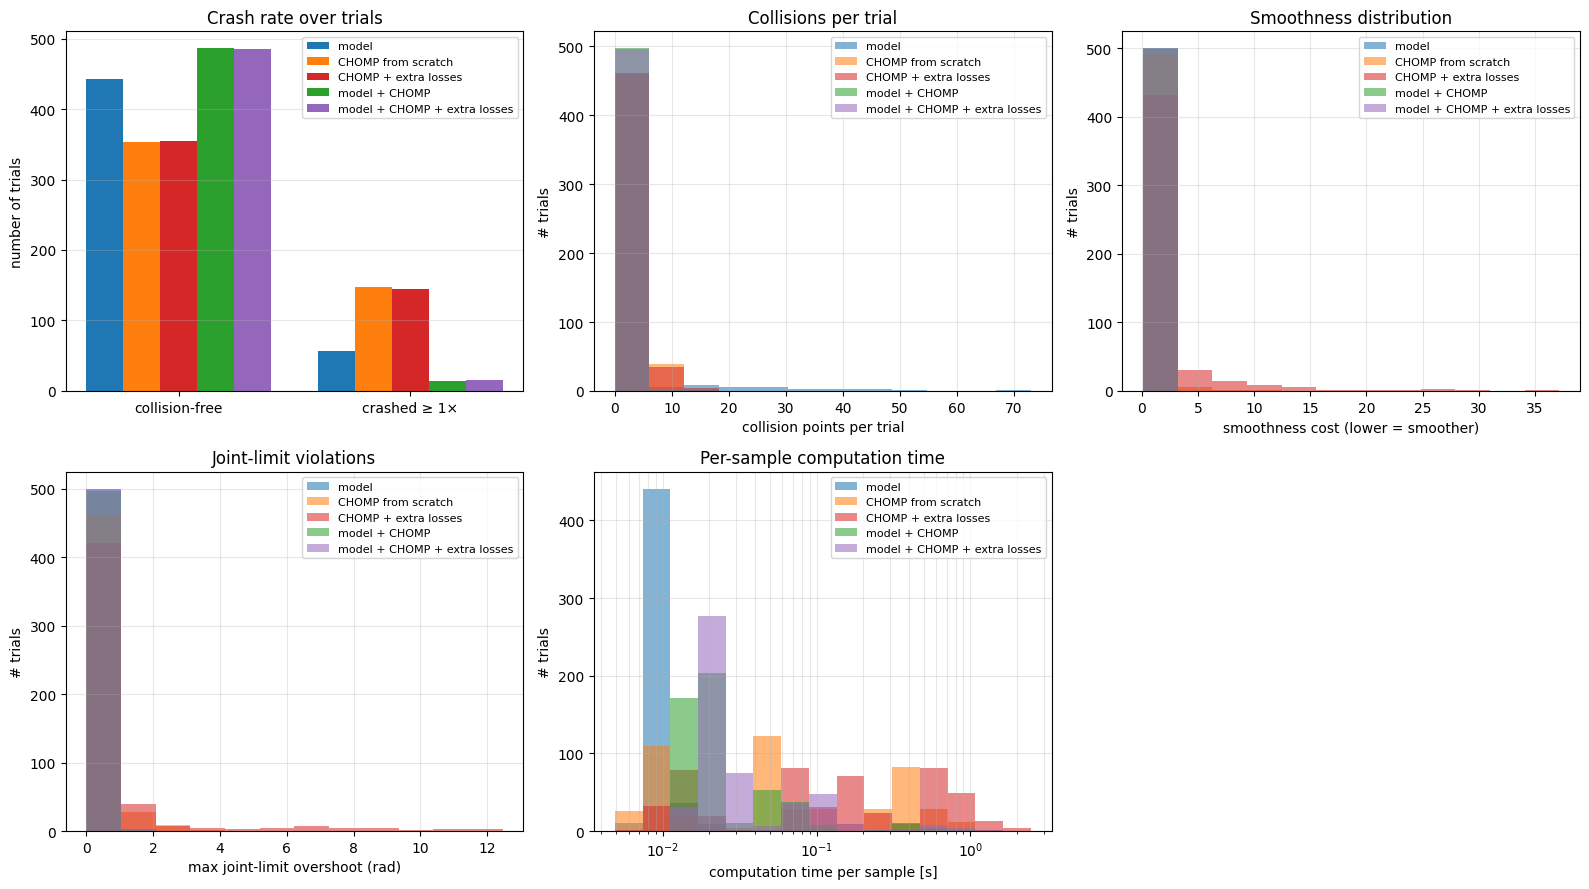

In [18]:
# ---- Distribution plots: one colour per method (see COLORS / METHODS above) ----
def vals(m, key):
    return [e[key] for e in results[m]["evals"]]


fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# (1) Crash rate — collision-free vs. crashed (>=1 collision) trials per method.
ax = axes[0, 0]
w  = 0.8 / len(METHODS)
x  = np.arange(2)
for j, m in enumerate(METHODS):
    free = sum(e["collision_free"] for e in results[m]["evals"])
    n    = len(results[m]["evals"])
    off  = (j - (len(METHODS) - 1) / 2) * w
    ax.bar(x + off, [free, n - free], w, label=m, color=COLORS[m])
ax.set_xticks(x); ax.set_xticklabels(["collision-free", "crashed ≥ 1×"])
ax.set_ylabel("number of trials"); ax.set_title("Crash rate over trials")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

# (2) How often it crashes — distribution of collision points per trial.
ax = axes[0, 1]
allc = [v for m in METHODS for v in vals(m, "n_collision_pts")]
bins = np.histogram_bin_edges(allc, bins=12) if max(allc) > 0 else np.arange(-0.5, 2.5)
for m in METHODS:
    ax.hist(vals(m, "n_collision_pts"), bins=bins, alpha=0.55, label=m, color=COLORS[m])
ax.set_xlabel("collision points per trial"); ax.set_ylabel("# trials")
ax.set_title("Collisions per trial"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (3) Smoothness — distribution of the smoothness cost (lower = smoother).
ax = axes[0, 2]
bins = np.histogram_bin_edges([v for m in METHODS for v in vals(m, "smooth")], bins=12)
for m in METHODS:
    ax.hist(vals(m, "smooth"), bins=bins, alpha=0.55, label=m, color=COLORS[m])
ax.set_xlabel("smoothness cost (lower = smoother)"); ax.set_ylabel("# trials")
ax.set_title("Smoothness distribution"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (4) Joint-limit violations — max overshoot (rad) per trial.
ax = axes[1, 0]
allj = [v for m in METHODS for v in vals(m, "joint_violation")]
if max(allj) <= 1e-6:
    ax.text(0.5, 0.5, "no joint-limit violations\nin any method", ha="center", va="center",
            transform=ax.transAxes, fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
else:
    bins = np.histogram_bin_edges(allj, bins=12)
    for m in METHODS:
        ax.hist(vals(m, "joint_violation"), bins=bins, alpha=0.55, label=m, color=COLORS[m])
    ax.set_xlabel("max joint-limit overshoot (rad)"); ax.set_ylabel("# trials")
    ax.legend(fontsize=8)
ax.set_title("Joint-limit violations"); ax.grid(alpha=0.3)

# (5) Computation time — distribution of per-sample wall-clock (log x: model ~ms, CHOMP ~s).
ax = axes[1, 1]
allt = [t for m in METHODS for t in results[m]["times"]]
bins = np.logspace(np.log10(min(allt)), np.log10(max(allt)), 16)
for m in METHODS:
    ax.hist(results[m]["times"], bins=bins, alpha=0.55, label=m, color=COLORS[m])
ax.set_xscale("log")
ax.set_xlabel("computation time per sample [s]"); ax.set_ylabel("# trials")
ax.set_title("Per-sample computation time"); ax.legend(fontsize=8); ax.grid(which="both", alpha=0.3)

axes[1, 2].axis("off")  # unused panel

plt.tight_layout(); plt.show()